In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение библиотек copy
import copy

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# координаты броуновской частицы,
# совершающей случайные блуждания
# в ограниченной справа области
def Walk_rigth(x0, X_max, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_max - координата отражающей стенки
    # Step - значение шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монет-Карло
    # p - пороговая вероятность

    # инициализация массива, используемого
    # для хранения координат
    # последних точек траекторий
    # броуновской частицы
    X = np.zeros(N_trial + 1)

    # сохранение значения
    # координаты начальной точки
    X[0] = x0

    # реализация метода Монте-Карло
    for i in range(1, N_trial):
        x = x0
        for j in range(N_step):
            # вычисление новой координаты
            # броуновской частицы
            if p >= random.uniform(0, 1):
                x = x + Step
                if x > X_max:
                    # если новая координата больше X_max,
                    # вычисление координаты
                    # броуновской частицы после
                    # отражения от правой границы
                    x = 2 * X_max - x
            else:
                x = x - Step

        # сохранение значений
        # координат последних точек
        # траектории броуновской частицы
        # на каждом шаге метода Монет-Карло
        X[i] = x

    return X


In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения плотности распределения
# случайной величины с ограниченной
# областью рассеяния (Zb)
def Pb(x, x0, Sigma, X_bound):
    # x - массив, содержащий
    #     координатную сетку,
    #     в узлах которой вычисляются
    #     значения элементов массивов Zn, Zim, Zb
    # x0 - математическое ожидание порождающего
    #      нормального распределения
    # Sigma - среднеквадратическое отклонение
    #         плотности распределения порождающего
    #         нормального распределения
    # X_max - координата правой границы области рассеяния

    # перемещение в массив X
    # значений элементов
    # массива х
    X = copy.copy(x)
    Np = len(X)

    # инициализация массива Zb
    Zb = np.zeros(Np)

    # вычисление плотностей распределений:
    # порождающего источника (Zn),
    # мнимого источника (Zim),
    # случайной с ограниченной справа
    #    областью рассеяния (Zb)
    #  в соответствие с (12.59)
    for i in range(Np):
        Zn = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((X[i] - x0) ** 2) / (2 * Sigma**2))
        )
        Zim = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((X[i] + x0 - 2 * X_bound) ** 2) / (2 * Sigma**2))
        )
        Zb[i] = Zn + Zim

    return Zb

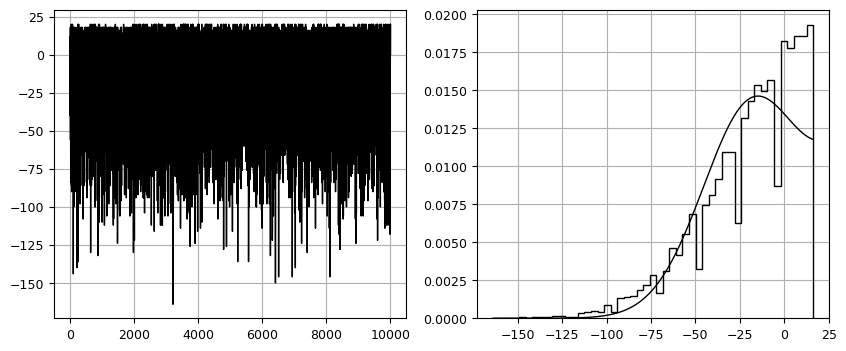

In [4]:
# Ячейка № 4

# инициализация генератора случайных чисел
random.seed()

# вычисление и визуализация
# случайной последовательности,
# составленной из значений
# координат точек, в которых
# оказывалась броуновская частица,
# стартовавшая из одной и той же
# начальной точки и совершавшая N_step шагов,
# ее гистограммы и соответствующей теоретической
# плотности распределения

# задание числа шагов
# броуновской частицы
N_step = 2 * 10**3

# задание числа испытаний
# метода Монте-Карло
N_trial = 1 * 10**4

# задание граничного значения
# вероятности смещения
p = 0.5

# задание начального положения
# броуновской частицы
x0 = 6

# задание координаты
# отражающей стенки
X_max = 20

# задание значения
# шага броуновской частицы
Step = 1

# вычисление ансамбля координат
# броуновской частицы, совершающей
# случайные блуждания в ограниченной справа области
M_rigth = Walk_rigth(x0, X_max, Step, N_step, N_trial, p)

# задание значений интервалов гистограммы
N_bin = 50
xbins = np.arange(
    np.min(M_rigth), np.max(M_rigth), (max(M_rigth) - min(M_rigth)) / N_bin
)

# вычисление среднего значения
# ансамбля координат случайных
# блужданий
M_mean = np.mean(M_rigth)

# вычисление дисперсии
# ансамбля координат случайных
# блужданий
M_std = np.std(M_rigth)

# вычисление координат узлов сетки,
# используемой для вычисления
# плотности распределения случайной величины
# с ограниченной областью рассеяния
x = np.linspace(np.min(xbins), np.max(xbins), 10**3)

# вычисление значений плотности
# нормального распределения
# N(M_mean,M_std)
dP_rigth = Pb(x, M_mean, M_std, X_max)

# визуализация сгенерированной
# случайной последовательности,
# ее гистограммы и плотности
# распределения
fig = plt.figure(figsize=(10, 4))


# визуализация ансамбля,
# составленного из значений
# координат последних точек
# траекторий броуновской частицы
plt.subplot(1, 2, 1)
plt.plot(M_rigth, "-k", lw=1)
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация гистограммы
# ансамбля координат
# случайных блужданий
plt.hist(M_rigth, bins=xbins, histtype="step", color="black", density=True)

# визуализация плотности
# плотности распределения
# случайной величины с ограниченной
# справа областью рассеяния
plt.plot(x, dP_rigth, "-k", lw=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(True)
plt.show()